In [1]:
import pandas as pd

<h2>#ЧАСТЬ 1: Классификация</h2>

In [2]:
titanic_train = pd.read_csv('./titanic_train.csv')

In [3]:
titanic_test = pd.read_csv('./titanic_test.csv')

In [4]:
original_titanic_test = pd.read_csv('./titanic_test.csv')

In [5]:
titanic_train.drop(columns=['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
titanic_test.drop(columns=['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

titanic_train = pd.get_dummies(titanic_train, columns=['Sex', 'Embarked'])
titanic_test = pd.get_dummies(titanic_test, columns=['Sex', 'Embarked'])

titanic_train.drop(columns=['Sex_male'], axis=1, inplace=True)
titanic_test.drop(columns=['Sex_male'], axis=1, inplace=True)

In [6]:
titanic_train_knn = titanic_train.copy(deep=True)
titanic_test_knn = titanic_test.copy(deep=True)

from sklearn.impute import KNNImputer

imputer = KNNImputer()
titanic_train_knn = imputer.fit_transform(titanic_train_knn)
titanic_test_knn = imputer.fit_transform(titanic_test_knn)

titanic_train = pd.DataFrame(data=titanic_train_knn, columns=['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Embarked_C', 'Embarked_Q', 'Embarked_S'])
titanic_test = pd.DataFrame(data=titanic_test_knn, columns=['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Embarked_C', 'Embarked_Q', 'Embarked_S'])

In [7]:
titanic_train.drop(columns=['Fare'], axis=1, inplace=True)
titanic_test.drop(columns=['Fare'], axis=1, inplace=True)

In [8]:
X_titanic =  titanic_train.drop(columns=['Survived', 'PassengerId'])
y_titanic = titanic_train['Survived']

In [9]:
X_titanic_test = titanic_test.drop(columns=['PassengerId'])

In [10]:
cols_to_normalize = ['Pclass', 'Age', 'SibSp', 'Parch']

X_titanic[cols_to_normalize] = X_titanic[cols_to_normalize].apply(
    lambda x: (x - x.min()) / (x.max() - x.min())
)
X_titanic_test[cols_to_normalize] = X_titanic_test[cols_to_normalize].apply(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

In [11]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=0)
X_titanic, y_titanic = ros.fit_resample(X_titanic, y_titanic)

In [12]:
from sklearn import model_selection

X_titanic_train, X_titanic_val, y_titanic_train, y_titanic_val = model_selection.train_test_split(X_titanic, y_titanic)

<h3>##Бэггинг</h3>

In [13]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

base_classifier = DecisionTreeClassifier(max_depth=7, min_samples_split=2)
bag_classifier = BaggingClassifier(estimator=base_classifier)

In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators' : [10, 20, 30, 50, 75, 100, 150, 200, 250, 300]
}

grid_search = GridSearchCV(bag_classifier, param_grid, cv=5)
grid_search.fit(X_titanic_train, y_titanic_train)

print("Best parameters found:")
print(grid_search.best_params_)

Best parameters found:
{'n_estimators': 20}


In [15]:
bag_classifier = BaggingClassifier(estimator=base_classifier, n_estimators=20)

In [16]:
bag_classifier.fit(X_titanic, y_titanic)
preds = bag_classifier.predict(X_titanic_test)

In [17]:
output_titanic_bagging = pd.DataFrame({'PassengerId': original_titanic_test['PassengerId'], 'Survived': preds})
output_titanic_bagging.to_csv('./titanic_bagging.csv', index=False)

<h3>##Бустинг</h3>

In [18]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

gb_classifier = GradientBoostingClassifier()

param_grid = {
    'n_estimators' : [10, 20, 30, 50, 75, 100, 150, 200, 250, 300],
    'learning_rate': [0.1, 0.01, 0.005]
}

grid_search = GridSearchCV(gb_classifier, param_grid, cv=5)
grid_search.fit(X_titanic_train, y_titanic_train)

print("Best parameters found:")
print(grid_search.best_params_)

Best parameters found:
{'learning_rate': 0.1, 'n_estimators': 20}


In [44]:
gb_classifier = GradientBoostingClassifier(n_estimators=20)

In [45]:
gb_classifier.fit(X_titanic, y_titanic)
preds = gb_classifier.predict(X_titanic_test)

In [46]:
output_titanic_boosting = pd.DataFrame({'PassengerId': original_titanic_test['PassengerId'], 'Survived': preds})
output_titanic_boosting.to_csv('./titanic_boosting.csv', index=False)

<h3>##Стэкинг</h3>

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier

base_models = [
    ('rf', RandomForestClassifier(n_estimators=100)),
    ('gb', GradientBoostingClassifier(n_estimators=20))
]

meta_model = KNeighborsClassifier(n_neighbors=9)

stacking_classifier = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)

In [48]:
stacking_classifier.fit(X_titanic, y_titanic)

StackingClassifier(cv=5,
                   estimators=[('rf', RandomForestClassifier()),
                               ('gb',
                                GradientBoostingClassifier(n_estimators=20))],
                   final_estimator=KNeighborsClassifier(n_neighbors=9))

In [49]:
preds = stacking_classifier.predict(X_titanic_test)
output_titanic_stacking = pd.DataFrame({'PassengerId': original_titanic_test['PassengerId'], 'Survived': preds})
output_titanic_stacking.to_csv('./titanic_stacking.csv', index=False)

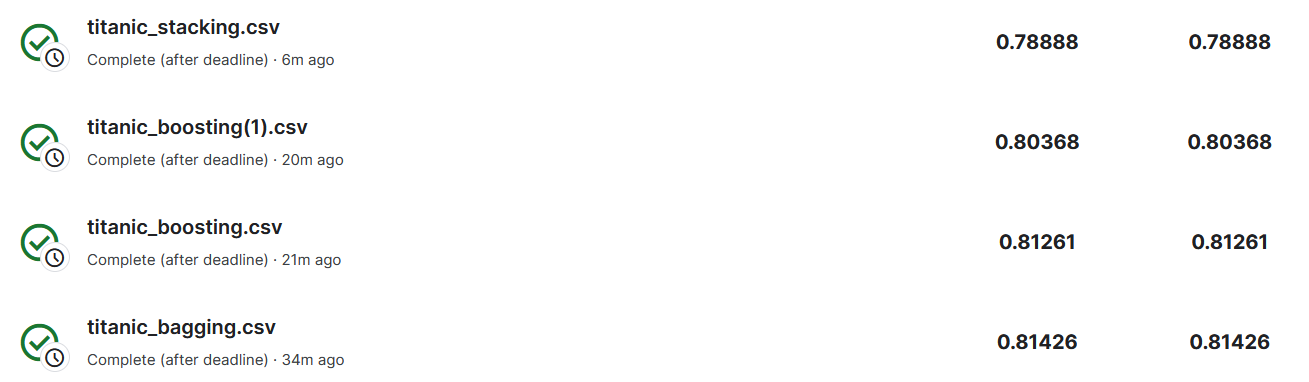

<h2>#Часть 2: Регрессия</h2>

In [26]:
flats_train = pd.read_csv('./train.csv')

In [27]:
flats_test = pd.read_csv('./test.csv')

In [28]:
original_flats_test = pd.read_csv('./test.csv')

In [29]:
# Вычисляем среднее и стандартное отклонение для каждого признака
mean = flats_train.mean()
std_dev = flats_train.std()

# Определяем границы для определения выбросов
lower_bound = mean - 3 * std_dev
upper_bound = mean + 3 * std_dev

# Удаляем выбросы
flats_train = flats_train[~((flats_train < lower_bound) | (flats_train > upper_bound)).any(axis=1)]

In [30]:
# Удаление признаков слабо коллерирующих с ценой
correlation_matrix = flats_train.corr()
correlation_threshold = 0.1

features_to_exclude = ['Цена']

weak_correlation_features = correlation_matrix[abs(correlation_matrix['Цена']) < correlation_threshold].index.tolist()
weak_correlation_features = [feature for feature in weak_correlation_features if feature not in features_to_exclude]

flats_train.drop(columns=weak_correlation_features, inplace=True)
flats_test.drop(columns=weak_correlation_features, inplace=True)

In [31]:
X_flats = flats_train.drop(columns=['Цена'])
y_flats = flats_train['Цена']

<h3>##Бэггинг</h3>

In [32]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

base_regressor = DecisionTreeRegressor(max_depth=5, min_samples_leaf=4, min_samples_split=10)
bag_regressor = BaggingRegressor(estimator=base_regressor)

In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators' : [10, 20, 30, 50, 75, 100, 150, 200, 250, 300]
}

grid_search = GridSearchCV(bag_regressor, param_grid, cv=5)
grid_search.fit(X_flats, y_flats)

print("Best parameters found:")
print(grid_search.best_params_)

Best parameters found:
{'n_estimators': 100}


Обработанный датасет: 30

Ориг. датасет: 200

In [34]:
bag_regressor = BaggingRegressor(estimator=base_regressor, n_estimators=200)

In [35]:
bag_regressor.fit(X_flats, y_flats)

BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=5,
                                                 min_samples_leaf=4,
                                                 min_samples_split=10),
                 n_estimators=200)

In [36]:
preds = bag_regressor.predict(flats_test)
output_flats_bagging = pd.DataFrame({'id': original_flats_test['id'], 'Цена': preds})
output_flats_bagging.to_csv('./flats_bagging.csv', index=False)

<h3>##Бустинг</h3>

In [37]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

gb_regressor = GradientBoostingRegressor()

param_grid = {
    'n_estimators' : [10, 20, 30, 50, 75, 100, 150, 200, 250, 300],
    'learning_rate': [0.1, 0.01, 0.005]
}

grid_search = GridSearchCV(gb_regressor, param_grid, cv=5)
grid_search.fit(X_flats, y_flats)

print("Best parameters found:")
print(grid_search.best_params_)

Best parameters found:
{'learning_rate': 0.1, 'n_estimators': 150}


Обработанный датасет: {'learning_rate': 0.1, 'n_estimators': 150}

Ориг. датасет: {'learning_rate': 0.1, 'n_estimators': 200}

In [38]:
gb_regressor = GradientBoostingRegressor(n_estimators=200)

In [39]:
gb_regressor.fit(X_flats, y_flats)

GradientBoostingRegressor(n_estimators=200)

In [40]:
preds = gb_regressor.predict(flats_test)
output_flats_boosting = pd.DataFrame({'id': original_flats_test['id'], 'Цена': preds})
output_flats_boosting.to_csv('./flats_boosting.csv', index=False)

<h3>##Стэкинг</h3>

In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Lasso

base_models = [
    ('rf', RandomForestRegressor(n_estimators=100)),
    ('gb', GradientBoostingRegressor(n_estimators=200))
]

meta_model = Lasso(alpha=999)

stacking_regressor = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)

In [42]:
stacking_regressor.fit(X_flats, y_flats)

StackingRegressor(cv=5,
                  estimators=[('rf', RandomForestRegressor()),
                              ('gb',
                               GradientBoostingRegressor(n_estimators=200))],
                  final_estimator=Lasso(alpha=999))

In [43]:
preds = stacking_regressor.predict(flats_test)
output_flats_stacking = pd.DataFrame({'id': original_flats_test['id'], 'Цена': preds})
output_flats_stacking.to_csv('./flats_stacking.csv', index=False)

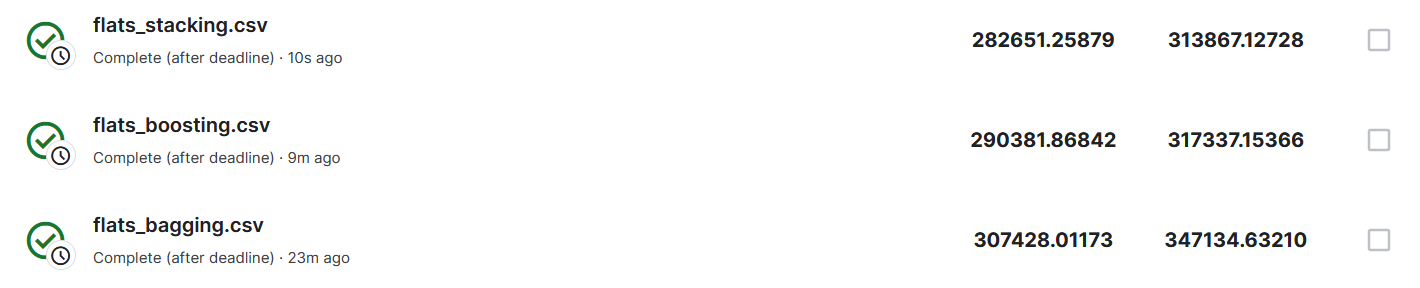

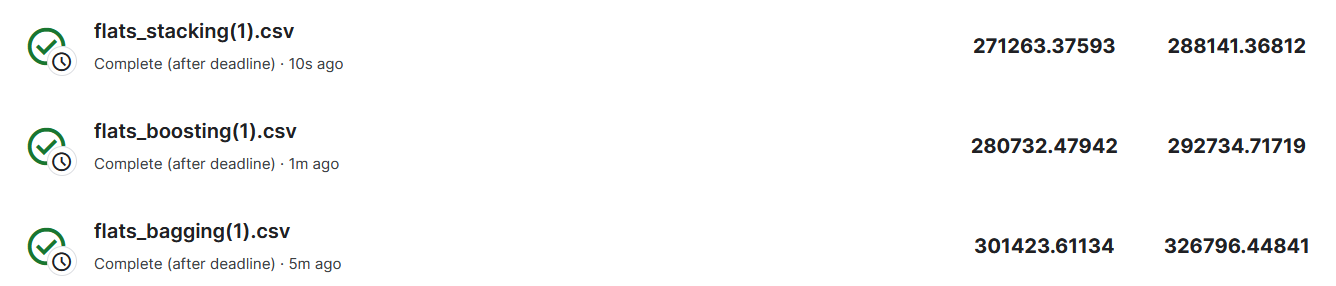